E-Commerce Customer Purchase Prediction

Name: Ancy John J.
Organization: Entri Elevate
Project Type: Machine Learning Classification Project

In [4]:
import os

os.getcwd()


'C:\\Users\\Ancy\\anaconda3\\condabin2\\anctjinu'

In [9]:
import zipfile

zip_file = "online+shoppers+purchasing+intention+dataset (1).zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(".")

In [2]:
import os

os.listdir()

['.ipynb_checkpoints',
 'anctjinu',
 'Ecommerce_Customer_Purchase_Prediction.ipynb',
 'online+shoppers+purchasing+intention+dataset (1).zip',
 'online_shoppers_intention.csv',
 'random_forest_model.pkl',
 'README.txt']

In [3]:
import pandas as pd

df = pd.read_csv("online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.shape

(12330, 18)

In [ ]:
Columns

In [5]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Data Types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
Missing Values officially check

In [7]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [ ]:
Duplicate Rows Remove

In [8]:
df = df.drop_duplicates()
df.shape

(12205, 18)

In [ ]:
Outliers Check

In [9]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

In [ ]:
find Outliers

In [10]:
Q1 = df['Administrative'].quantile(0.25)
Q3 = df['Administrative'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower =", lower)
print("Upper =", upper)

Q1 = 0.0
Q3 = 4.0
IQR = 4.0
Lower = -6.0
Upper = 10.0


In [11]:
print(df['Administrative'].max())

27


In [12]:
df[df['Administrative'] > 10].shape

(404, 18)

In [13]:
df['Administrative'].describe()

count    12205.000000
mean         2.338878
std          3.330436
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         27.000000
Name: Administrative, dtype: float64

In [ ]:
Outlier Checking – Step 2

In [13]:
columns = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, ":", len(outliers))

Administrative : 404
Administrative_Duration : 1149
Informational : 2631
Informational_Duration : 2405
ProductRelated : 1007
ProductRelated_Duration : 951
BounceRates : 1428
ExitRates : 1325
PageValues : 2730
SpecialDay : 1249


In [ ]:
Skewness

In [14]:
df[columns].skew()

Administrative             1.947123
Administrative_Duration    5.592152
Informational              4.014173
Informational_Duration     7.540291
ProductRelated             4.333419
ProductRelated_Duration    7.253161
BounceRates                3.162425
ExitRates                  2.234645
PageValues                 6.350983
SpecialDay                 3.285902
dtype: float64

In [ ]:
EDA

In [ ]:
EDA – Step 1: Target Variable Analysis

In [15]:
df['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

In [ ]:
Step 2 — Graph

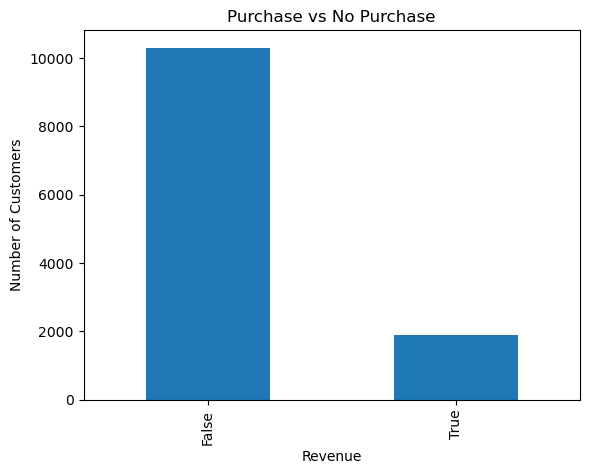

In [15]:
import matplotlib.pyplot as plt

df['Revenue'].value_counts().plot(kind='bar')

plt.title('Purchase vs No Purchase')
plt.xlabel('Revenue')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
Numerical Features Distribution

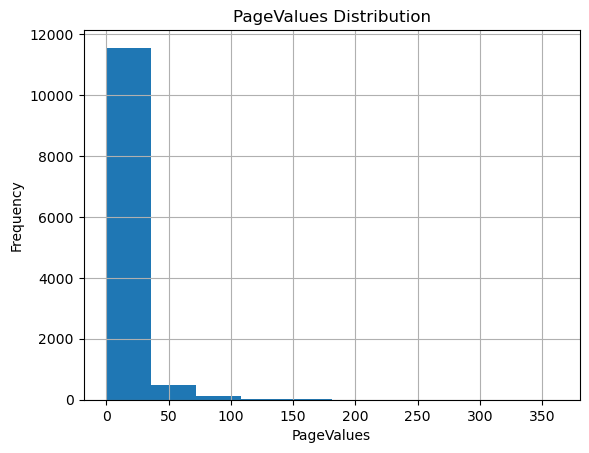

In [16]:
df['PageValues'].hist()

plt.title('PageValues Distribution')
plt.xlabel('PageValues')
plt.ylabel('Frequency')
plt.show()

In [ ]:
PageValues vs Revenue graph

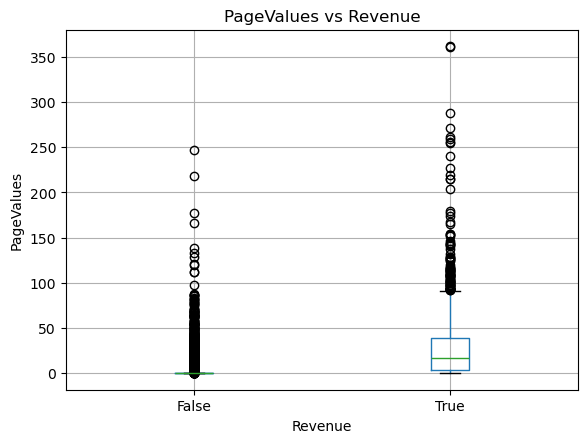

In [17]:
df.boxplot(column='PageValues', by='Revenue')

plt.title('PageValues vs Revenue')
plt.suptitle('')
plt.xlabel('Revenue')
plt.ylabel('PageValues')
plt.show()

In [ ]:
EDA: Correlation Heatmap

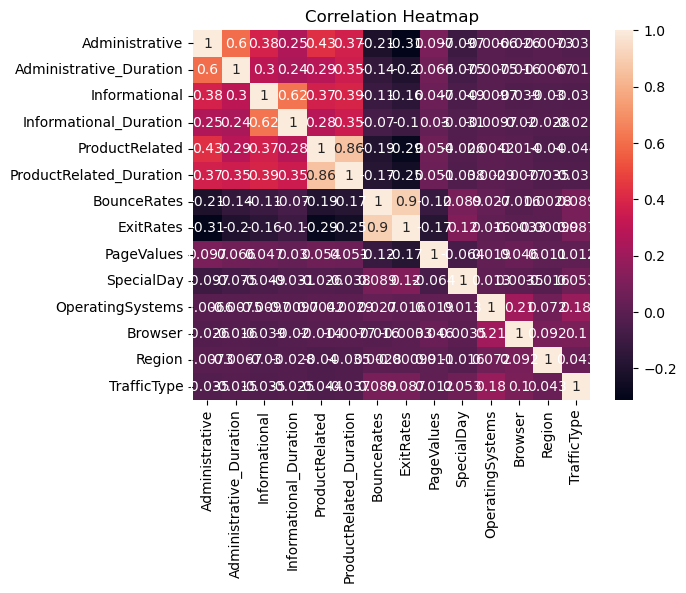

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(corr, annot=True)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
VisitorType vs Revenue

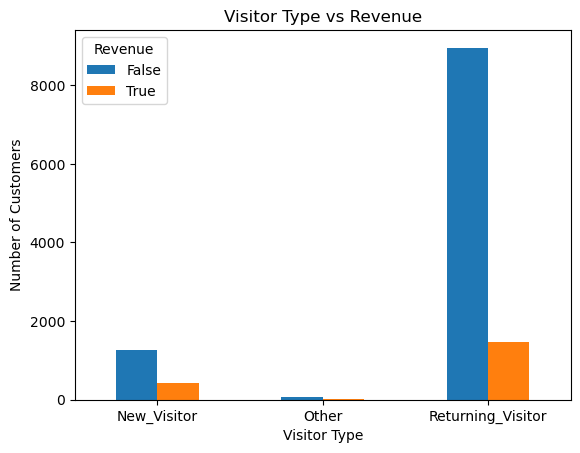

In [19]:
pd.crosstab(df['VisitorType'], df['Revenue']).plot(kind='bar')

plt.title('Visitor Type vs Revenue')
plt.xlabel('Visitor Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [ ]:
 EDA Month vs Revenue

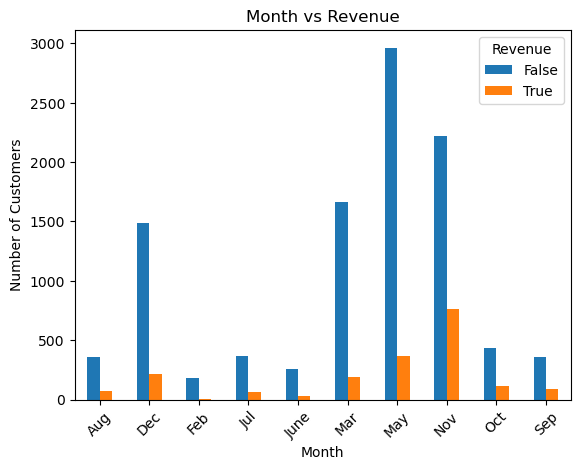

In [20]:
pd.crosstab(df['Month'], df['Revenue']).plot(kind='bar')

plt.title('Month vs Revenue')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [ ]:
Weekend vs Revenue

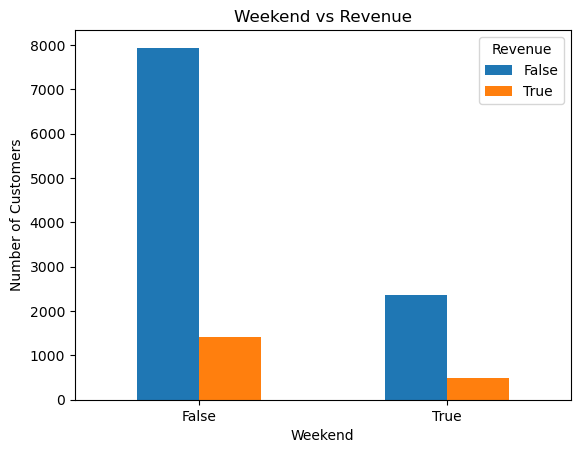

In [21]:
pd.crosstab(df['Weekend'], df['Revenue']).plot(kind='bar')

plt.title('Weekend vs Revenue')
plt.xlabel('Weekend')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [ ]:
ProductRelated vs Revenue

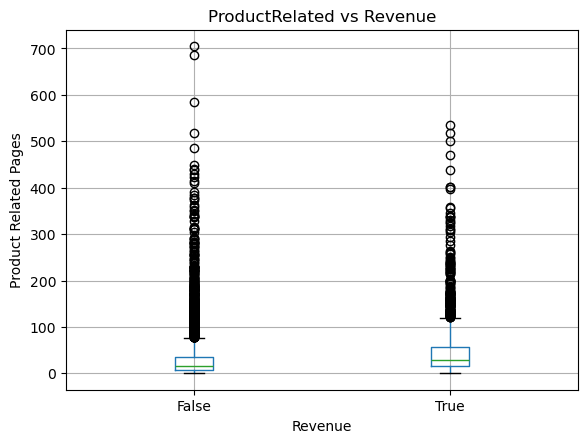

In [22]:
df.boxplot(column='ProductRelated', by='Revenue')

plt.title('ProductRelated vs Revenue')
plt.suptitle('')
plt.xlabel('Revenue')
plt.ylabel('Product Related Pages')
plt.show()

In [ ]:
Feature Engineering

In [24]:
df.select_dtypes(include='object').columns

Index(['Month', 'VisitorType'], dtype='object')

In [23]:
print(df['Month'].unique())
print(df['VisitorType'].unique())

['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
['Returning_Visitor' 'New_Visitor' 'Other']


In [ ]:
🔥 Step 1 — Encoding

In [24]:
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [ ]:
Target Separation 

In [25]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']
print(X.shape)
print(y.shape)

(12205, 26)
(12205,)


In [ ]:
Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9764, 26)
(2441, 26)
(9764,)
(2441,)


In [ ]:
Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(9764, 26)
(2441, 26)


In [ ]:
ML Models

In [ ]:
Logistic Regression
Decision Tree
Random Forest
SVM
KNN

In [ ]:
Logistic Regression

In [28]:

#Import
from sklearn.linear_model import LogisticRegression
#Model create
lr_model = LogisticRegression(max_iter=1000)
#Train
lr_model.fit(X_train_scaled, y_train)
#Prediction
y_pred_lr = lr_model.predict(X_test_scaled)
print(y_pred_lr)
print(y_pred_lr[:10])

[False False False ...  True False False]
[False False False False False False False False False False]


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.889389594428513
Precision: 0.7718446601941747
Recall: 0.4162303664921466
F1 Score: 0.5408163265306123


In [ ]:
Accuracy, Precision, Recall, F1 Score

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.889389594428513
Precision: 0.7718446601941747
Recall: 0.4162303664921466
F1 Score: 0.5408163265306123


In [ ]:
Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.8603031544448996
Precision: 0.5535248041775457
Recall   : 0.5549738219895288
F1 Score : 0.5542483660130719


In [ ]:
Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.9082343301925441
Precision: 0.7687074829931972
Recall   : 0.5916230366492147
F1 Score : 0.6686390532544378


In [ ]:
SVM

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create model
svm_model = SVC()

# Train model
svm_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("SVM Results")
print("-----------")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

SVM Results
-----------
Accuracy : 0.8947152806226956
Precision: 0.751004016064257
Recall   : 0.4895287958115183
F1 Score : 0.5927099841521395


In [ ]:
KNN

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Results")
print("-----------")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

KNN Results
-----------
Accuracy : 0.8734125358459648
Precision: 0.6682027649769585
Recall   : 0.3795811518324607
F1 Score : 0.48414023372287146


In [ ]:
Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

print("Parameter grid created successfully!")

Parameter grid created successfully!


In [35]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'n_estimators': 200}
Best F1 Score: 0.6433971890301422


In [ ]:
Tuned Random Forest Test

In [36]:
best_rf_model = grid_search.best_estimator_

y_pred_tuned = best_rf_model.predict(X_test)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))

Tuned Random Forest Results
---------------------------
Accuracy : 0.9037279803359279
Precision: 0.745819397993311
Recall   : 0.5837696335078534
F1 Score : 0.6549192364170338


In [ ]:
ROC-AUC + Confusion Matrix

In [ ]:
ROC-AUC:

In [37]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.9248669485771825


In [ ]:
Confusion Matrix

Confusion Matrix:
[[1991   68]
 [ 156  226]]


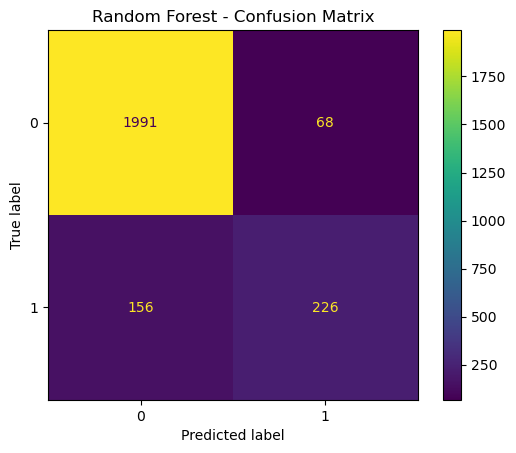

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
Model Comparison Code

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_knn)
    ]
})

comparison

NameError: name 'y_pred_knn' is not defined

In [ ]:
Model Save

In [42]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
Saved Model Load

In [43]:
import joblib

loaded_model = joblib.load("random_forest_model.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
Unseen Customer Prediction

In [ ]:
Step 1 — Test customer

In [44]:
new_customer = X_test.iloc[[0]]

print("New Customer Data:")
print(new_customer)
print("\nShape:", new_customer.shape)

New Customer Data:
       Administrative  Administrative_Duration  Informational  \
11757               0                      0.0              0   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
11757                     0.0              12                    482.5   

       BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_Feb  \
11757         0.02       0.04         0.0         0.0  ...      False   

       Month_Jul  Month_June  Month_Mar  Month_May  Month_Nov  Month_Oct  \
11757      False       False      False      False       True      False   

       Month_Sep  VisitorType_Other  VisitorType_Returning_Visitor  
11757      False              False                           True  

[1 rows x 26 columns]

Shape: (1, 26)


In [ ]:
Step 2 — Prediction

In [45]:
prediction = loaded_model.predict(new_customer)[0]

print("Prediction:", prediction)

if prediction:
    print("Result: Customer is likely to make a Purchase.")
else:
    print("Result: Customer is likely NOT to make a Purchase.")

Prediction: False
Result: Customer is likely NOT to make a Purchase.


In [ ]:
 Probability

In [46]:
probability = loaded_model.predict_proba(new_customer)[0]

print("No Purchase Probability:", probability[0])
print("Purchase Probability:", probability[1])

No Purchase Probability: 0.89
Purchase Probability: 0.11


In [ ]:
Feature Columns Save

In [47]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Feature columns saved successfully!")
print("Number of features:", len(X.columns))

Feature columns saved successfully!
Number of features: 26


In [1]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\Ancy\anaconda3\condabin2\anctjinu
['.ipynb_checkpoints', 'Ecommerce_Customer_Purchase_Prediction.ipynb', 'feature_columns.pkl', 'online+shoppers+purchasing+intention+dataset (1).zip', 'online_shoppers_intention.csv', 'random_forest_model.pkl']


In [ ]:
Feature Selection — Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

feature_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

feature_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                    Feature  Importance
8                PageValues    0.364297
5   ProductRelated_Duration    0.091774
7                 ExitRates    0.087852
4            ProductRelated    0.069622
1   Administrative_Duration    0.058308
6               BounceRates    0.057283
0            Administrative    0.041386
13              TrafficType    0.031643
12                   Region    0.031095
3    Informational_Duration    0.027301


In [ ]:
✅ Feature Selection — SelectKBest

In [33]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates',
       'PageValues', 'Month_Nov', 'VisitorType_Returning_Visitor'],
      dtype='object')


In [ ]:
Pipeline

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

pipeline_score = pipeline.score(X_test, y_test)

print("Pipeline Accuracy:", pipeline_score)

Pipeline Accuracy: 0.9082343301925441


In [ ]:
ROC Curve Graph

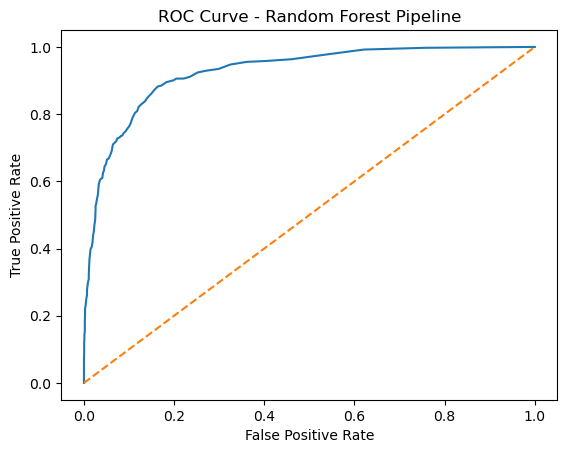

ROC-AUC Score: 0.9249247970218857


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_pipeline = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_pipeline)

auc_score = roc_auc_score(y_test, y_prob_pipeline)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Pipeline")
plt.show()

print("ROC-AUC Score:", auc_score)

Interpretation of Results (Conclusion)

In this project, different machine learning classification algorithms were used to predict whether an online customer would make a purchase. Logistic Regression, Decision Tree, Random Forest, SVM, and KNN models were trained and evaluated.

Among the models, Random Forest performed the best based on the model evaluation results. Hyperparameter tuning was also performed to improve the Random Forest model. The model achieved an ROC-AUC score of 92.49%, showing good ability to distinguish between customers who make a purchase and those who do not.

Feature selection using Random Forest Feature Importance and SelectKBest helped identify the most relevant features. PageValues was found to be the most important feature in the Random Forest feature importance analysis.

The final model was saved and tested with unseen customer data successfully.

Limitations

The model performance depends on the quality and distribution of the available dataset. The model may not perform equally well on completely different or future customer data.

Future Work

Use more recent customer data to improve the model.

Explore advanced machine learning and deep learning techniques.

Add more useful customer-related features.

Handle class imbalance if required.

Retrain the model periodically with new data.

Deploy the model as a web application for real-world use.